In [56]:
import os
os.system("pip install -q lightgbm shap")

0

In [57]:
try:
    from google.colab import files
    print("Upload your kaggle.json file:")
    files.upload()                          # select kaggle.json
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    os.rename("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    print("kaggle.json installed.")
except ModuleNotFoundError:
    print("Not on Colab — make sure ~/.kaggle/kaggle.json exists locally.")

os.system("kaggle datasets download -d sulianova/cardiovascular-disease-dataset --unzip -p ./data")
print("Dataset downloaded to ./data/")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
kaggle.json installed.
Dataset downloaded to ./data/


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import shap
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              ConfusionMatrixDisplay, roc_curve, auc)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SEED = 42

In [82]:
# ── 3. LOAD & INSPECT ─────────────────────────────────────────
# Dataset uses semicolons as separators
df = pd.read_csv("./data/cardio_train.csv", sep=";")
print(f"Raw shape: {df.shape}")
print(f"Exact duplicates: {df.duplicated().sum()}")
print(df.head())

# Drop id — not a feature
df = df.drop(columns=["id"])

# Convert age from days → years
df["age"] = (df["age"] / 365.25).round(1)

Raw shape: (70000, 13)
Exact duplicates: 0
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [83]:
# age         : age in years (converted from days)
# gender      : 1=female, 2=male
# height      : cm
# weight      : kg
# ap_hi       : systolic blood pressure
# ap_lo       : diastolic blood pressure
# cholesterol : 1=normal, 2=above normal, 3=well above normal
# gluc        : 1=normal, 2=above normal, 3=well above normal
# smoke       : binary (0/1)
# alco        : alcohol intake binary (0/1)
# active      : physical activity binary (0/1)
# cardio      : target — cardiovascular disease present (0/1df.head()

In [84]:
df = df.drop_duplicates()
print(f"Shape after removing dups: {df.shape}")

# ── Sanity / outlier removal ──────────────────────────────────
df = df[(df["ap_hi"] > 0)   & (df["ap_lo"] > 0)]
df = df[(df["ap_hi"] < 300) & (df["ap_lo"] < 200)]
df = df[df["ap_hi"] >= df["ap_lo"]]          # systolic must be >= diastolic
df = df[(df["height"] >= 100) & (df["height"] <= 250)]
df = df[(df["weight"] >= 30)  & (df["weight"] <= 200)]

print(f"Shape after cleaning: {df.shape}")


Shape after removing dups: (69326, 12)
Shape after cleaning: (68004, 12)


In [85]:
# BMI
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Hypertension
df["hypertension"] = ((df["ap_hi"] >= 140) | (df["ap_lo"] >= 90)).astype(int)

# Normalize values
age_min, age_max   = df["age"].min(), df["age"].max()
aphi_min, aphi_max = df["ap_hi"].min(), df["ap_hi"].max()
bmi_min, bmi_max   = df["bmi"].min(), df["bmi"].max()

def make_risk_score(row):
    age_score  = (row["age"] - age_min) / (age_max - age_min)
    bp_score   = (row["ap_hi"] - aphi_min) / (aphi_max - aphi_min)
    bmi_score  = (row["bmi"] - bmi_min) / (bmi_max - bmi_min)
    chol_score = (row["cholesterol"] - 1) / 2.0
    return 0.30*age_score + 0.30*bp_score + 0.25*bmi_score + 0.15*chol_score

df["risk_score"] = df.apply(make_risk_score, axis=1)

In [86]:
# Bin into 3 classes using risk_score, but enforce consistency
# with the original binary label:
#   cardio=0 → Low (0) or Medium (1) only
#   cardio=1 → Medium (1) or High (2) only

In [87]:
def assign_class(row):
    s = row["risk_score"]
    if row["cardio"] == 0:
        return 0 if s < 0.45 else 1
    else:
        return 1 if s < 0.55 else 2

df["risk_class"] = df.apply(assign_class, axis=1)

print("\nClass distribution:")
print(df["risk_class"].value_counts().sort_index()
      .rename({0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}))



Class distribution:
risk_class
Low Risk       29082
Medium Risk    34020
High Risk       4902
Name: count, dtype: int64


EDA

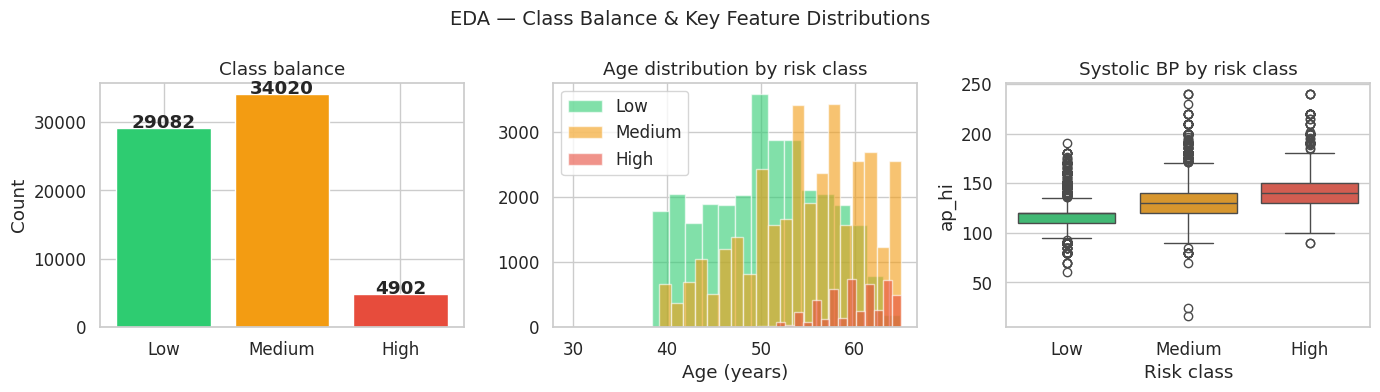

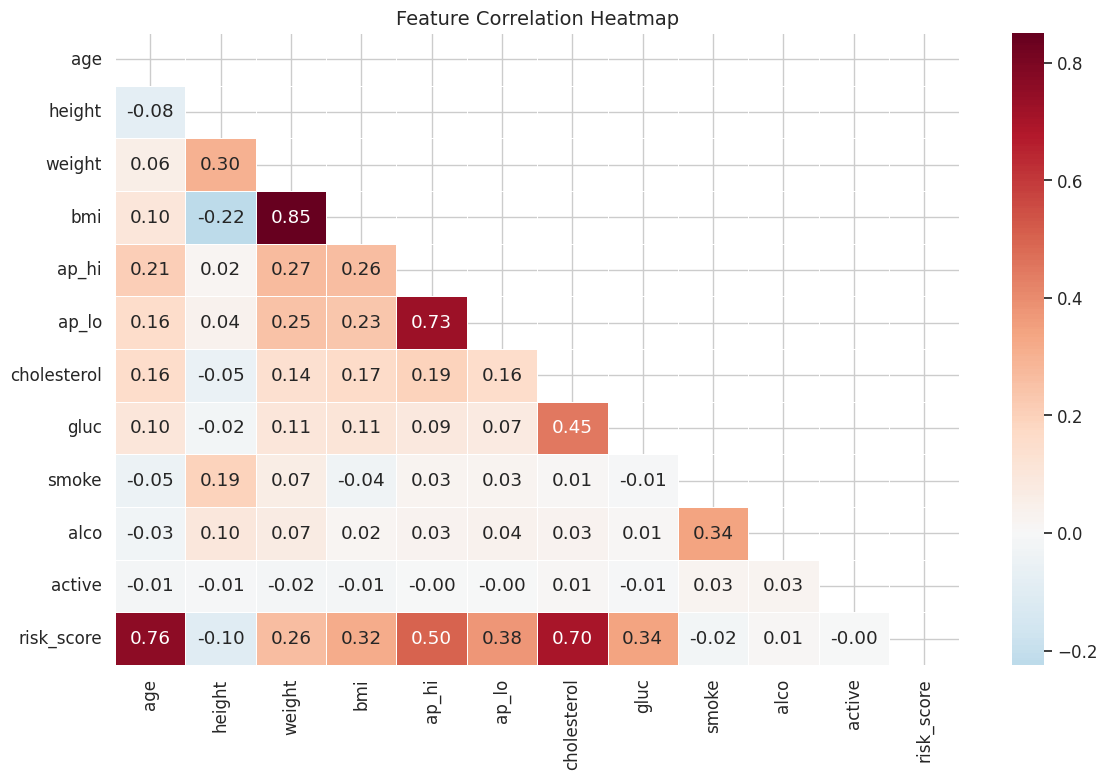

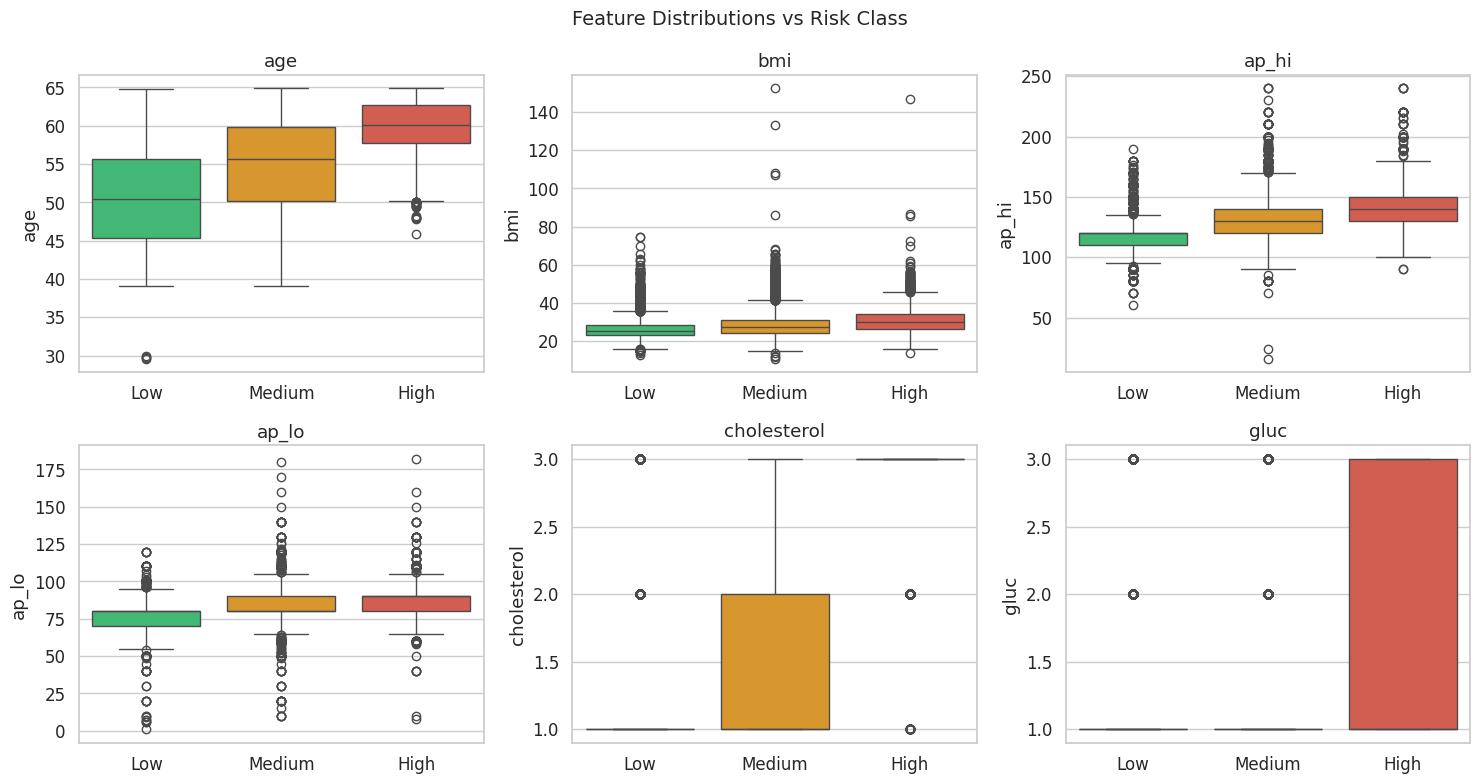


Missing values:
age             0
gender          0
height          0
weight          0
ap_hi           0
ap_lo           0
cholesterol     0
gluc            0
smoke           0
alco            0
active          0
cardio          0
bmi             0
hypertension    0
risk_score      0
risk_class      0
dtype: int64

Outlier counts per feature (IQR method):
  age: 4 outliers
  bmi: 1915 outliers
  ap_hi: 1015 outliers
  ap_lo: 3537 outliers
  weight: 1737 outliers
  height: 478 outliers


In [88]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("EDA — Class Balance & Key Feature Distributions", fontsize=14)

# 5a. Class balance
class_counts = df["risk_class"].value_counts().sort_index()
axes[0].bar(["Low", "Medium", "High"], class_counts.values,
            color=["#2ecc71","#f39c12","#e74c3c"], edgecolor="white")
axes[0].set_title("Class balance")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# 5b. Age distribution by class
for cls, color, label in zip([0,1,2],
                              ["#2ecc71","#f39c12","#e74c3c"],
                              ["Low","Medium","High"]):
    subset = df[df["risk_class"] == cls]["age"]
    axes[1].hist(subset, bins=20, alpha=0.6, color=color, label=label)
axes[1].set_title("Age distribution by risk class")
axes[1].set_xlabel("Age (years)")
axes[1].legend()

# 5c. Systolic BP by class
sns.boxplot(data=df, x="risk_class", y="ap_hi", ax=axes[2],
            palette=["#2ecc71","#f39c12","#e74c3c"])
axes[2].set_xticklabels(["Low","Medium","High"])
axes[2].set_title("Systolic BP by risk class")
axes[2].set_xlabel("Risk class")

plt.tight_layout()
plt.show()

# 5d. Correlation heatmap (numeric columns only)
plt.figure(figsize=(12, 8))
num_df = df[["age","height","weight","bmi","ap_hi","ap_lo",
             "cholesterol","gluc","smoke","alco","active","risk_score"]]
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, mask=mask, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# 5e. Feature distributions vs risk class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Feature Distributions vs Risk Class", fontsize=14)
features = ["age", "bmi", "ap_hi", "ap_lo", "cholesterol", "gluc"]
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x="risk_class", y=feat, ax=ax,
                palette=["#2ecc71","#f39c12","#e74c3c"])
    ax.set_xticklabels(["Low","Medium","High"])
    ax.set_title(feat)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

# 5f. Missing value check
print("\nMissing values:")
print(df.isnull().sum())

# 5g. Outlier check (IQR method)
print("\nOutlier counts per feature (IQR method):")
num_cols = ["age","bmi","ap_hi","ap_lo","weight","height"]
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {outliers} outliers")

In [89]:
print("\nOutlier counts:")

for col in ["age", "bmi", "ap_hi", "ap_lo", "weight", "height"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[col] < Q1 - 1.5*IQR) |
                (df[col] > Q3 + 1.5*IQR)).sum()

    print(f"{col}: {outliers}")


Outlier counts:
age: 4
bmi: 1915
ap_hi: 1015
ap_lo: 3537
weight: 1737
height: 478


feature engineering

In [90]:
df["pulse_pressure"]      = df["ap_hi"] - df["ap_lo"]          # arterial stiffness marker
df["age_bmi_interaction"] = df["age"]   * df["bmi"]            # obesity-age combined risk
df["bp_ratio"]            = df["ap_hi"] / (df["ap_lo"] + 1)    # systolic/diastolic ratio
df["bmi_age_ratio"]       = df["bmi"]   / (df["age"] + 1)      # relative BMI for age
df["chol_gluc_product"]   = df["cholesterol"] * df["gluc"]     # metabolic syndrome proxy
df["lifestyle_score"]     = df["smoke"] + df["alco"] - df["active"]
# lifestyle_score: -1 = active non-smoker/drinker  ->  +2 = smoking + drinking + inactive

df = pd.get_dummies(df, columns=["cholesterol", "gluc"], drop_first=True)

X = df.drop(columns=["cardio", "risk_score", "risk_class"])
y = df["risk_class"]

print(f"\nFinal feature set: {X.shape[1]} features, {len(y)} samples")
print("Features:", X.columns.tolist())


Final feature set: 21 features, 68004 samples
Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'bmi', 'hypertension', 'pulse_pressure', 'age_bmi_interaction', 'bp_ratio', 'bmi_age_ratio', 'chol_gluc_product', 'lifestyle_score', 'cholesterol_2', 'cholesterol_3', 'gluc_2', 'gluc_3']


test train spilt

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)




Train: (54403, 21) | Test: (13601, 21)


basee models

In [92]:
# ── 8. BASE MODELS ──────────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=4,
    random_state=SEED,
    n_jobs=-1
)

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

svc = CalibratedClassifierCV(
    LinearSVC(max_iter=2000, random_state=SEED),
    cv=3
)

stacking classifier

In [96]:
# The stacking CV (n_splits=5) generates out-of-fold predictions from
# each base model, which the meta-learner (LogReg) trains on.
# passthrough=True also feeds the raw scaled features to the meta-learner,
# giving it more signal to work with.
# No separate cross_val_score call — it's redundant given the internal CV.

stack_model = StackingClassifier(
    estimators=[
        ("rf",   rf),
        ("lgbm", lgbm),
        ("svc",  svc),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        C=1.0,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=SEED
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    passthrough=True,
    n_jobs=-1
)

print("\nTraining stacking model (RF + LightGBM + LinearSVC -> LogReg meta)...")
stack_model.fit(X_train_scaled, y_train)
print("Training complete.")



Training stacking model (RF + LightGBM + LinearSVC -> LogReg meta)...
Training complete.


evaluation

In [97]:
y_pred     = stack_model.predict(X_test_scaled)
y_proba    = stack_model.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro")

print(f"\nTest Accuracy     : {acc:.4f}")
print(f"ROC-AUC (macro OvR): {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=["Low Risk", "Medium Risk", "High Risk"]))



Test Accuracy     : 0.7775
ROC-AUC (macro OvR): 0.9103

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.73      0.83      0.78      5817
 Medium Risk       0.82      0.71      0.76      6804
   High Risk       0.82      0.92      0.86       980

    accuracy                           0.78     13601
   macro avg       0.79      0.82      0.80     13601
weighted avg       0.78      0.78      0.78     13601



visualisation

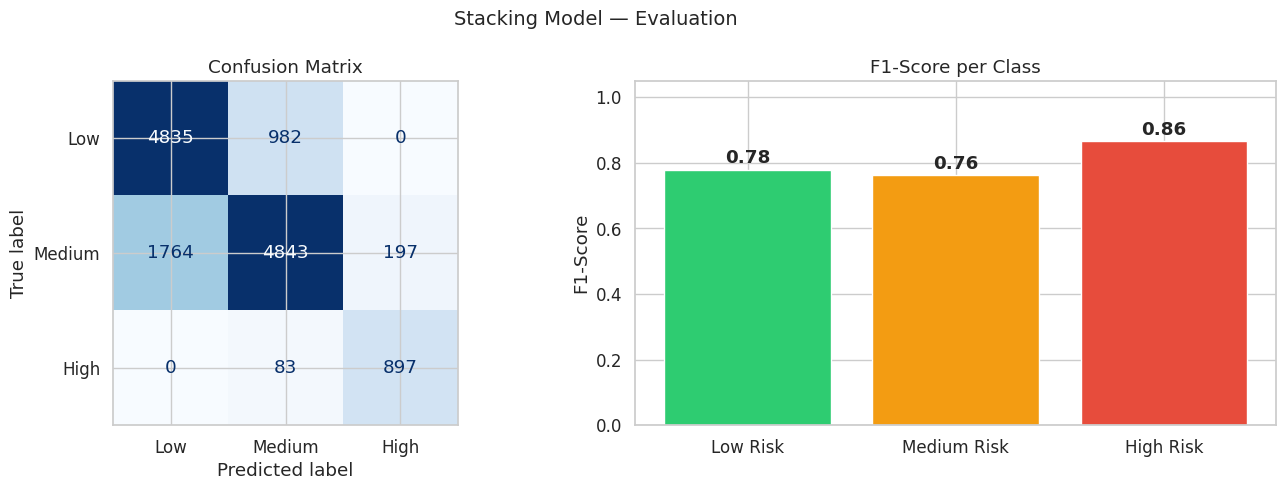

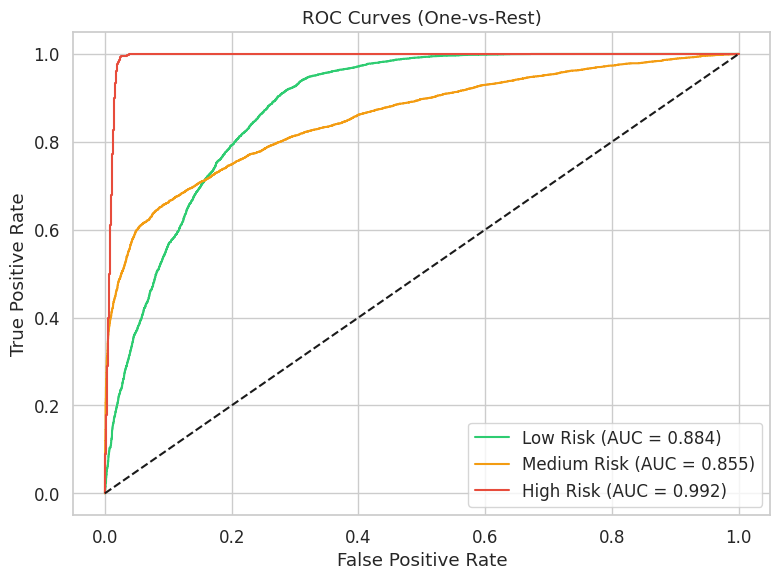

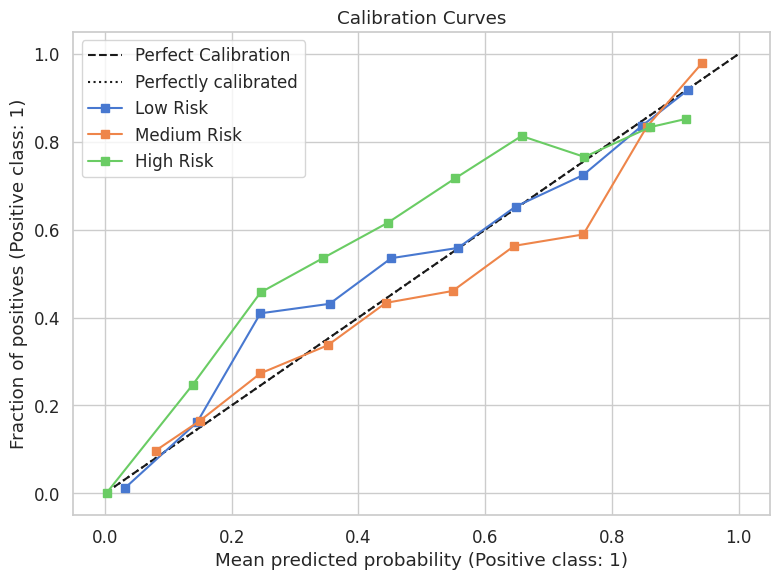

In [98]:
# ── 11. EVALUATION VISUALIZATION (FIXED) ───────────────────

classes = ["Low Risk", "Medium Risk", "High Risk"]
colors  = ["#2ecc71", "#f39c12", "#e74c3c"]

# IMPORTANT: Binarize labels for ROC & calibration
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])


# ── 11a. Confusion Matrix + F1 Score ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stacking Model — Evaluation", fontsize=14)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# F1 Score
report = classification_report(
    y_test,
    y_pred,
    target_names=classes,
    output_dict=True
)

f1_scores = [report[c]["f1-score"] for c in classes]

axes[1].bar(classes, f1_scores, color=colors)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("F1-Score per Class")
axes[1].set_ylabel("F1-Score")

for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


# ── 11b. ROC Curves ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

for i, (name, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, color=color,
            label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (One-vs-Rest)")
ax.legend()

plt.tight_layout()
plt.show()


# ── 11c. Calibration Curves ───────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

for i, (name, color) in enumerate(zip(classes, colors)):
    CalibrationDisplay.from_predictions(
        y_test_bin[:, i],
        y_proba[:, i],
        n_bins=10,
        ax=ax,
        name=name
    )

ax.set_title("Calibration Curves")
ax.legend()

plt.tight_layout()
plt.show()

SHAP shape: (500, 21, 3)


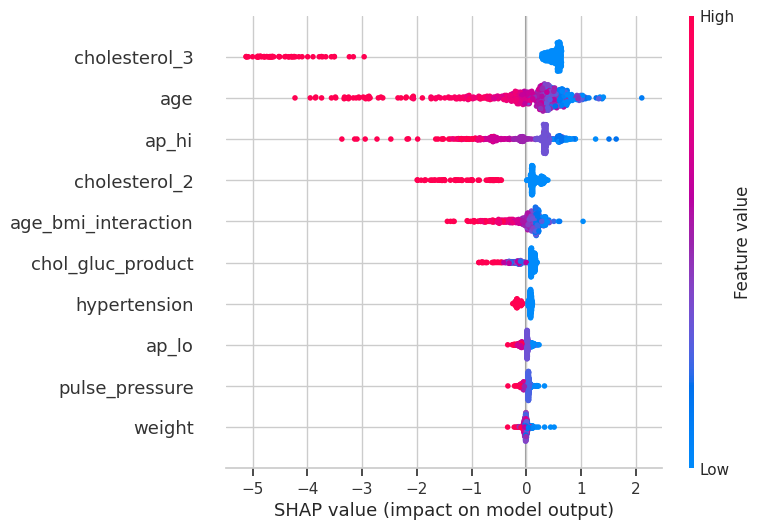

<Figure size 640x480 with 0 Axes>

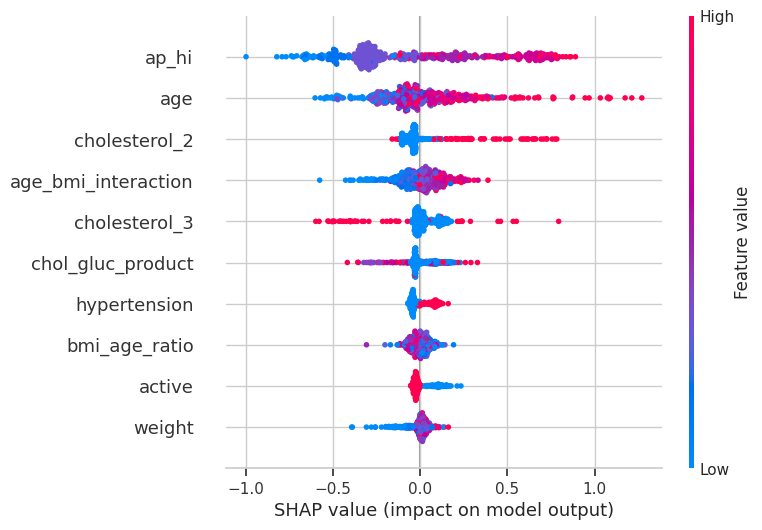

<Figure size 640x480 with 0 Axes>

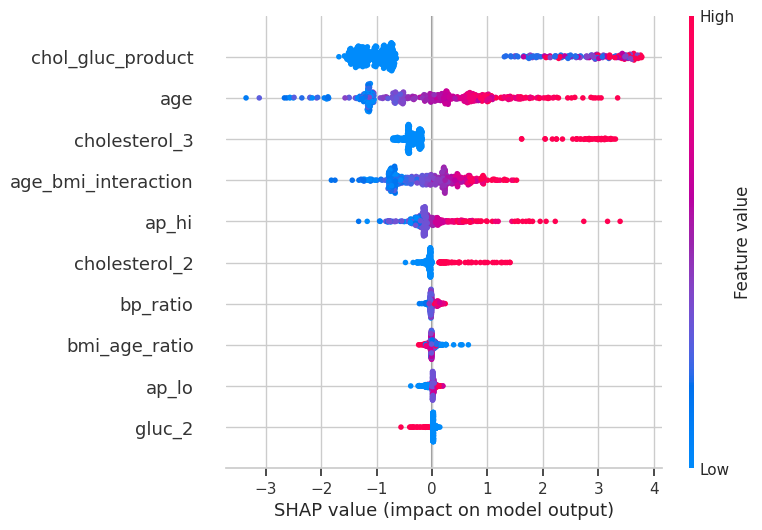

<Figure size 640x480 with 0 Axes>

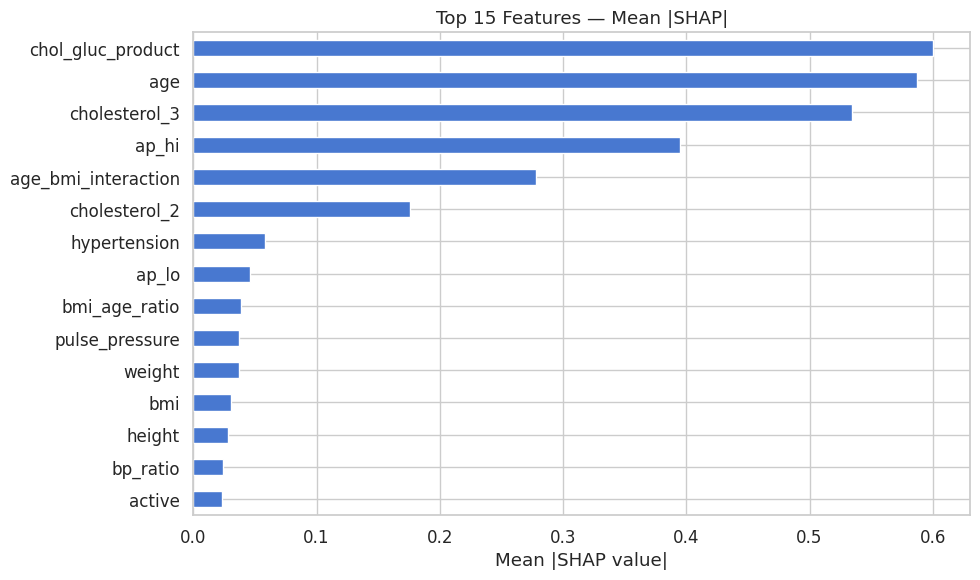


Top 10 important features:
chol_gluc_product      0.600518
age                    0.587542
cholesterol_3          0.534326
ap_hi                  0.394994
age_bmi_interaction    0.278421
cholesterol_2          0.175964
hypertension           0.058539
ap_lo                  0.045843
bmi_age_ratio          0.038968
pulse_pressure         0.036754
dtype: float64


In [100]:
# ── 12. SHAP EXPLANATION (FIXED) ─────────────────────────────

# Get trained LightGBM model from stacking
fitted_lgbm = stack_model.named_estimators_["lgbm"]

# Convert scaled test data back to DataFrame
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Sample data (for speed)
shap_sample = X_test_df.sample(
    n=min(500, len(X_test_df)), random_state=SEED
)

# Create SHAP explainer (TreeExplainer works best for LightGBM)
explainer = shap.TreeExplainer(fitted_lgbm)

# Compute SHAP values
shap_values = explainer.shap_values(shap_sample)

# Handle different SHAP versions
# New versions → list of arrays (one per class)
# Old versions → 3D array
if isinstance(shap_values, list):
    shap_array = np.stack(shap_values, axis=2)   # (samples, features, classes)
else:
    shap_array = shap_values

print("SHAP shape:", shap_array.shape)
# Expected: (n_samples, n_features, 3)

# ── 12a. Beeswarm plots ─────────────────────────────────────
# ── FINAL FIXED SHAP PLOTS ─────────────────────────────

classes = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(3):
    shap.summary_plot(
        shap_array[:, :, i],
        shap_sample,
        plot_type="dot",
        max_display=10,
        show=True   # IMPORTANT: let SHAP handle display
    )

    # Add title AFTER plot is rendered
    plt.gcf().suptitle(f"SHAP Summary — {classes[i]}", fontsize=14)
    plt.tight_layout()
    plt.show()
# ── 12b. Global Feature Importance ───────────────────────────

# Mean absolute SHAP across all classes
mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

shap_importance = pd.Series(
    mean_abs_shap, index=X.columns
).sort_values(ascending=False)

# Plot top features
plt.figure(figsize=(10, 6))
shap_importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Features — Mean |SHAP|")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 important features:")
print(shap_importance.head(10))

Testing

In [103]:

sample = X_test.iloc[0:1]   # take one patient

# Scale it
sample_scaled = scaler.transform(sample)

# Predict
pred = stack_model.predict(sample_scaled)[0]
proba = stack_model.predict_proba(sample_scaled)[0]

# Convert to label
label_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}

print("Predicted Class:", label_map[pred])
print("Probabilities:", proba)

actual = y_test.iloc[0]

print("Actual:", label_map[actual])
print("Predicted:", label_map[pred])

Predicted Class: Medium Risk
Probabilities: [0.14170707 0.85715277 0.00114016]
Actual: Medium Risk
Predicted: Medium Risk


In [105]:
# ── CUSTOM INPUT TEST ─────────────────────────────

new_data = pd.DataFrame([{
    "age": 95,
    "gender": 2,
    "height": 170,
    "weight": 80,
    "ap_hi": 190,
    "ap_lo": 95,
    "smoke": 1,
    "alco": 1,
    "active": 0,

    # engineered features (MUST match training)
    "bmi": 80 / (1.7**2),
    "hypertension": 1,
    "pulse_pressure": 150 - 95,
    "age_bmi_interaction": 55 * (80/(1.7**2)),
    "bp_ratio": 150 / (95 + 1),
    "bmi_age_ratio": (80/(1.7**2)) / (55 + 1),
    "chol_gluc_product": 2 * 1,
    "lifestyle_score": 1 + 0 - 0,

    # encoded columns
    "cholesterol_2": 1,
    "cholesterol_3": 0,
    "gluc_2": 0,
    "gluc_3": 0
}])

# Align columns
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# Scale
new_scaled = scaler.transform(new_data)

# Predict
pred = stack_model.predict(new_scaled)[0]

label_map = {0: "Low Risk", 1: "Medium Risk", 2: "High Risk"}

print("Prediction:", label_map[pred])

Prediction: High Risk
